# Quick Start Tutorial

- [Link](https://ts.gluon.ai/stable/tutorials/forecasting/quick_start_tutorial.html)

GluonTS contains:

* A number of pre-built models
* Components for building new models (likelihoods, feature processing pipelines, calendar features etc.)
* Data loading and processing
* Plotting and evaluation facilities
* Artificial and real datasets (only external datasets with blessed license)

In [47]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

## Datasets

### Provided datasets

GluonTS comes with a number of publicly available datasets.

In [48]:
from gluonts.dataset.repository import get_dataset, dataset_names
from gluonts.dataset.util import to_pandas

In [49]:
for i, name in enumerate(dataset_names):
    print(f"{i + 1}: {name}")

1: constant
2: exchange_rate
3: solar-energy
4: electricity
5: traffic
6: exchange_rate_nips
7: electricity_nips
8: traffic_nips
9: solar_nips
10: wiki2000_nips
11: wiki-rolling_nips
12: taxi_30min
13: kaggle_web_traffic_with_missing
14: kaggle_web_traffic_without_missing
15: kaggle_web_traffic_weekly
16: m1_yearly
17: m1_quarterly
18: m1_monthly
19: nn5_daily_with_missing
20: nn5_daily_without_missing
21: nn5_weekly
22: tourism_monthly
23: tourism_quarterly
24: tourism_yearly
25: cif_2016
26: london_smart_meters_without_missing
27: wind_farms_without_missing
28: car_parts_without_missing
29: dominick
30: fred_md
31: pedestrian_counts
32: hospital
33: covid_deaths
34: kdd_cup_2018_without_missing
35: weather
36: m3_monthly
37: m3_quarterly
38: m3_yearly
39: m3_other
40: m4_hourly
41: m4_daily
42: m4_weekly
43: m4_monthly
44: m4_quarterly
45: m4_yearly
46: m5
47: uber_tlc_daily
48: uber_tlc_hourly
49: airpassengers
50: australian_electricity_demand
51: electricity_hourly
52: electricity

To download one of the built-in datasets, simply call get_dataset with one of the above names. GluonTS can re-use the saved dataset so that it does not need to be downloaded again the next time around.

In [50]:
dataset = get_dataset("m4_hourly")

In general, the datasets provided by GluonTS are objects that consists of three main members:

- `dataset.train` is an iterable collection of data entries used for training. Each entry corresponds to one time series.
- `dataset.test` is an iterable collection of data entries used for inference. The test dataset is an extended version of the train dataset that contains a window in the end of each time series that was not seen during training. This window has length equal to the recommended prediction length.
- `dataset.metadata` contains metadata of the dataset such as the frequency of the time series, a recommended prediction horizon, associated features, etc.

dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])


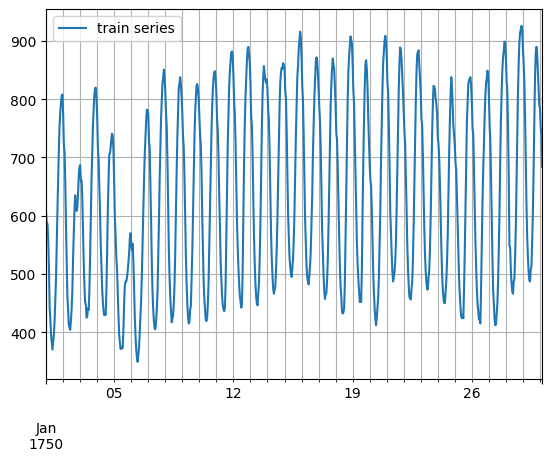

In [78]:
entry = next(iter(dataset.train))  # dict
print(entry.keys())
train_series = to_pandas(entry)
train_series.plot()
plt.grid(which="both")
plt.legend(["train series"], loc="upper left")
plt.show()

dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])


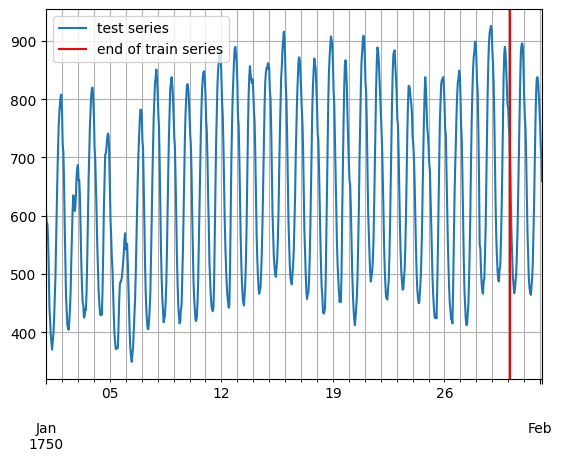

In [79]:
entry = next(iter(dataset.test))  # dict
print(entry.keys())
test_series = to_pandas(entry)
test_series.plot()
plt.axvline(train_series.index[-1], color="r")  # end of train dataset
plt.grid(which="both")
plt.legend(["test series", "end of train series"], loc="upper left")
plt.show()

In [53]:
print(
    f"Length of forecasting window in test dataset: {len(test_series) - len(train_series)}"
)
print(f"Recommended prediction horizon: {dataset.metadata.prediction_length}")
print(f"Frequency of the time series: {dataset.metadata.freq}")

Length of forecasting window in test dataset: 48
Recommended prediction horizon: 48
Frequency of the time series: H


### Custom datasets

At this point, it is important to emphasize that GluonTS does not require this specific format for a custom dataset that a user may have. The only requirements for a custom dataset are to be iterable and have a "target" and a "start" field. To make this more clear, assume the common case where a dataset is in the form of a `numpy.array` and the index of the time series in a `pandas.Period` (possibly different for each time series):

In [54]:
N = 10  # number of time series
T = 100  # number of timesteps
prediction_length = 24
freq = "1H"
custom_dataset = np.random.normal(size=(N, T))
start = pd.Period("01-01-2019", freq=freq)  # can be different for each time series

C:\Users\Mike\AppData\Local\Temp\ipykernel_27400\2007592095.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = pd.Period("01-01-2019", freq=freq)  # can be different for each time series


Now, you can split your dataset and bring it in a GluonTS appropriate format with just two lines of code:

In [55]:
from gluonts.dataset.common import ListDataset

In [56]:
# train dataset: cut the last window of length "prediction_length", add "target" and "start" fields
train_ds = ListDataset(
    [{"target": x, "start": start} for x in custom_dataset[:, :-prediction_length]],
    freq=freq,
)
# test dataset: use the whole dataset, add "target" and "start" fields
test_ds = ListDataset(
    [{"target": x, "start": start} for x in custom_dataset], freq=freq
)

c:\Users\Mike\anaconda3\envs\gifteval\Lib\site-packages\gluonts\dataset\common.py:255: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ProcessDataEntry(to_offset(freq), one_dim_target, use_timestamp),


## Training an existing model (`Estimator`)

GluonTS comes with a number of pre-built models. All the user needs to do is configure some hyperparameters. The existing models focus on (but are not limited to) probabilistic forecasting. Probabilistic forecasts are predictions in the form of a probability distribution, rather than simply a single point estimate.

We will begin with GluonTS's pre-built feedforward neural network estimator, a simple but powerful forecasting model. We will use this model to demonstrate the process of training a model, producing forecasts, and evaluating the results.

GluonTS's built-in feedforward neural network (`SimpleFeedForwardEstimator`) accepts an input window of length `context_length` and predicts the distribution of the values of the subsequent `prediction_length` values. In GluonTS parlance, the feedforward neural network model is an example of an `Estimator`. In GluonTS, `Estimator` objects represent a forecasting model as well as details such as its coefficients, weights, etc.

In general, each estimator (pre-built or custom) is configured by a number of hyperparameters that can be either common (but not binding) among all estimators (e.g., the `prediction_length`) or specific for the particular estimator (e.g., number of layers for a neural network or the stride in a CNN).

Finally, each estimator is configured by a `Trainer`, which defines how the model will be trained i.e., the number of epochs, the learning rate, etc.

In [57]:
from gluonts.torch.model.simple_feedforward import SimpleFeedForwardEstimator

In [58]:
estimator = SimpleFeedForwardEstimator(
    prediction_length=dataset.metadata.prediction_length,
    context_length=100,
    hidden_dimensions=[10],
    lr=1e-3,
    num_batches_per_epoch=100,
    trainer_kwargs={
        "max_epochs": 5,
    },
)

After specifying our estimator with all the necessary hyperparameters we can train it using our training dataset `dataset.train` by invoking the `train` method of the estimator. The training algorithm returns a fitted model (or a `Predictor` in GluonTS parlance) that can be used to construct forecasts.

In [59]:
predictor = estimator.train(dataset.train)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\Mike\anaconda3\envs\gifteval\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: 
  | Name  | Type                   | Param

Training: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 100: 'train_loss' reached 5.32611 (best 5.32611), saving model to 'c:\\Users\\Mike\\vscode\\gift-eval\\notebooks\\gluonts\\lightning_logs\\version_5\\checkpoints\\epoch=0-step=100.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 100: 'train_loss' reached 5.32611 (best 5.32611), saving model to 'c:\\Users\\Mike\\vscode\\gift-eval\\notebooks\\gluonts\\lightning_logs\\version_5\\checkpoints\\epoch=0-step=100.ckpt' as top 1
INFO: Epoch 1, global step 200: 'train_loss' reached 4.70778 (best 4.70778), saving model to 'c:\\Users\\Mike\\vscode\\gift-eval\\notebooks\\gluonts\\lightning_logs\\version_5\\checkpoints\\epoch=1-step=200.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 200: 'train_loss' reached 4.70778 (best 4.70778), saving model to 'c:\\Users\\Mike\\vscode\\gift-eval\\notebooks\\gluonts\\lightning_logs\\version_5\\checkpoints\\epoch=1-step=200.ckpt' as top 1
INFO: Epoch 2, global step 300: 'train

## Visualize and evaluate forecasts

With a predictor in hand, we can now predict the last window of the `dataset.test` and evaluate our model's performance.

GluonTS comes with the `make_evaluation_predictions` function that automates the process of prediction and model evaluation. Roughly, this function performs the following steps:

- Removes the final window of length `prediction_length` of the `dataset.test` that we want to predict
- The estimator uses the remaining data to predict (in the form of sample paths) the "future" window that was just removed
- The module outputs the forecast sample paths and the `dataset.test` (as python generator objects)

In [60]:
from gluonts.evaluation import make_evaluation_predictions

In [80]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=dataset.test,
    predictor=predictor,
)

print(type(forecast_it))
print(type(ts_it))

<class 'generator'>
<class 'map'>


First, we can convert these generators to lists to ease the subsequent computations.

In [62]:
forecasts = list(forecast_it)
tss = list(ts_it)

We can examine the first element of these lists (that corresponds to the first time series of the dataset). Let's start with the list containing the time series, i.e., `tss`. We expect the first entry of `tss` to contain the (target of the) first time series of `dataset.test`.

In [63]:
# first entry of the time series list
ts_entry = tss[0]

In [64]:
# first 5 values of the time series (convert from pandas to numpy)
np.array(ts_entry[:5]).reshape(
    -1,
)

array([605., 586., 586., 559., 511.], dtype=float32)

In [65]:
# first entry of dataset.test
dataset_test_entry = next(iter(dataset.test))

In [66]:
# first 5 values
dataset_test_entry["target"][:5]

array([605., 586., 586., 559., 511.], dtype=float32)

The entries in the `forecast` list are a bit more complex. They are objects that contain all the sample paths in the form of `numpy.ndarray` with dimension `(num_samples, prediction_length)`, the start date of the forecast, the frequency of the time series, etc. We can access all this information by simply invoking the corresponding attribute of the forecast object.

In [67]:
# first entry of the forecast list
forecast_entry = forecasts[0]

In [68]:
print(f"Start date of the forecast window: {forecast_entry.start_date}")
print(f"Frequency of the time series: {forecast_entry.freq}")

Start date of the forecast window: 1750-01-30 04:00
Frequency of the time series: <Hour>


We can also do calculations to summarize the sample paths, such as computing the mean or a quantile for each of the 48 time steps in the forecast window.

In [69]:
print(f"Mean of the future window:\n {forecast_entry.mean}")
print(f"0.5-quantile (median) of the future window:\n {forecast_entry.quantile(0.5)}")

Mean of the future window:
 [593.83246 651.1002  496.1405  504.4263  480.71268 496.79736 474.4815
 510.5323  545.36566 510.04648 553.7338  631.55817 695.9627  693.12054
 837.7388  758.4965  869.5604  751.54126 742.67865 859.7829  914.1057
 754.50934 812.9394  730.8599  669.80457 525.6256  470.67838 581.44055
 545.22766 510.8623  379.00027 405.69458 522.68835 482.40054 529.51654
 584.7494  645.55414 759.79224 832.3602  853.2592  824.22577 923.2805
 800.07245 887.12726 856.5384  887.4646  798.5601  743.42175]
0.5-quantile (median) of the future window:
 [593.83246 651.1002  496.1405  504.4263  480.71268 496.79736 474.4815
 510.5323  545.36566 510.04648 553.7338  631.55817 695.9627  693.12054
 837.7388  758.4965  869.5604  751.54126 742.67865 859.7829  914.1057
 754.50934 812.9394  730.8599  669.80457 525.6256  470.67838 581.44055
 545.22766 510.8623  379.00027 405.69458 522.68835 482.40054 529.51654
 584.7494  645.55414 759.79224 832.3602  853.2592  824.22577 923.2805
 800.07245 887.1272

`Forecast` objects have a `plot` method that can summarize the forecast paths as the mean, prediction intervals, etc. The prediction intervals are shaded in different colors as a "fan chart".

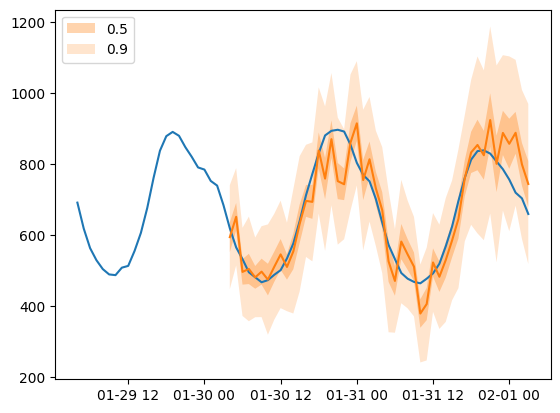

In [ ]:
plt.plot(ts_entry[-prediction_length * 3 :].to_timestamp())
forecast_entry.plot(show_label=True)
plt.legend()

We can also evaluate the quality of our forecasts numerically. In GluonTS, the `Evaluator` class can compute aggregate performance metrics, as well as metrics per time series (which can be useful for analyzing performance across heterogeneous time series).

In [71]:
from gluonts.evaluation import Evaluator

In [84]:
evaluator = Evaluator(quantiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
agg_metrics, item_metrics = evaluator(tss, forecasts)

Running evaluation: 414it [00:04, 98.48it/s]


The aggregate metrics, `agg_metrics`, aggregate both across time-steps and across time series.

In [85]:
print(json.dumps(agg_metrics, indent=4))

{
    "MSE": 15038432.20158694,
    "abs_error": 12560784.311191559,
    "abs_target_sum": 145558863.59960938,
    "abs_target_mean": 7324.822041043146,
    "seasonal_error": 336.9046924038305,
    "MASE": 5.893696366418041,
    "MAPE": 0.24049371111412174,
    "sMAPE": 0.20301464290002694,
    "MSIS": 58.5743350310401,
    "num_masked_target_values": 0.0,
    "QuantileLoss[0.1]": 5482206.043966389,
    "Coverage[0.1]": 0.10517310789049919,
    "QuantileLoss[0.2]": 8276260.149794199,
    "Coverage[0.2]": 0.20219404186795492,
    "QuantileLoss[0.3]": 10549798.960588265,
    "Coverage[0.3]": 0.2873389694041868,
    "QuantileLoss[0.4]": 12073398.970841218,
    "Coverage[0.4]": 0.36971618357487923,
    "QuantileLoss[0.5]": 12560784.381484985,
    "Coverage[0.5]": 0.4438909017713365,
    "QuantileLoss[0.6]": 12067183.59947567,
    "Coverage[0.6]": 0.5161533816425121,
    "QuantileLoss[0.7]": 10633386.122123146,
    "Coverage[0.7]": 0.5702495974235104,
    "QuantileLoss[0.8]": 8721243.651204

Individual metrics are aggregated only across time-steps.

In [88]:
print(item_metrics.shape)
item_metrics.head()

(414, 31)


,item_id,forecast_start,MSE,abs_error,abs_target_sum,abs_target_mean,seasonal_error,MASE,MAPE,sMAPE,...,QuantileLoss[0.5],Coverage[0.5],QuantileLoss[0.6],Coverage[0.6],QuantileLoss[0.7],Coverage[0.7],QuantileLoss[0.8],Coverage[0.8],QuantileLoss[0.9],Coverage[0.9]
0,0,1750-01-30 04:00,4428.299479,2470.961914,31644.0,659.250000,42.371302,1.214935,0.078612,0.078098,...,2470.962097,0.500000,2424.306165,0.625000,2230.455457,0.729167,1927.710645,0.854167,1307.829437,0.958333
1,1,1750-01-30 04:00,144542.687500,14373.947266,124149.0,2586.437500,165.107988,1.813705,0.121172,0.109939,...,14373.947144,0.854167,13901.127246,0.958333,12908.452661,1.000000,10840.986133,1.000000,7467.217505,1.000000
2,2,1750-01-30 04:00,45591.708333,8660.196289,65030.0,1354.791667,78.889053,2.287019,0.125217,0.135261,...,8660.196594,0.208333,8876.640161,0.229167,8226.217017,0.250000,6291.822168,0.312500,2766.032739,0.687500
3,3,1750-01-30 04:00,460725.458333,27234.503906,235783.0,4912.145833,258.982249,2.190828,0.116362,0.119944,...,27234.503174,0.354167,26905.297949,0.437500,24419.937793,0.458333,19184.786230,0.604167,10105.109863,0.812500
4,4,1750-01-30 04:00,104794.020833,12658.738281,131088.0,2731.000000,200.494083,1.315369,0.096439,0.094097,...,12658.738281,0.583333,12278.303809,0.625000,10528.237939,0.708333,8181.074561,0.875000,6138.604395,1.000000


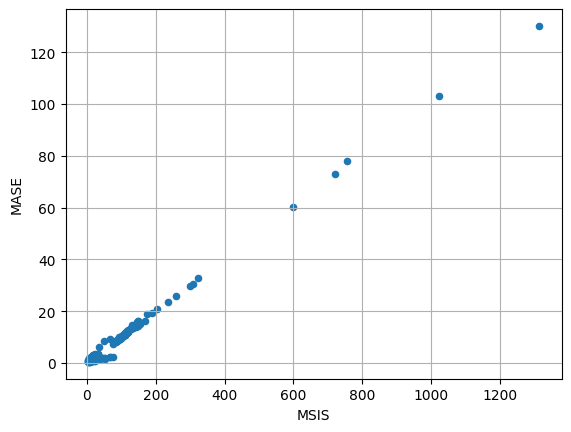

In [87]:
item_metrics.plot(x="MSIS", y="MASE", kind="scatter")
plt.grid(which="both")
plt.show()